[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


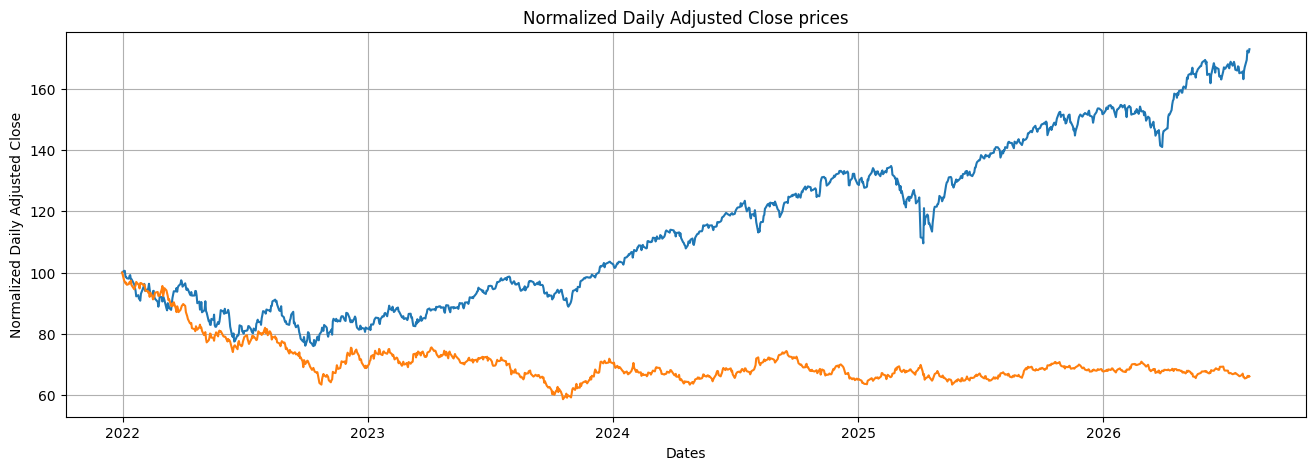

In [ ]:
import yfinance as yf
import pandas as pd

#SPY
spy_df = yf.download("SPY", start="2021-12-31", end="2026-08-10", auto_adjust=False)
spy_df_adjCl=spy_df.iloc[:,[0]]

#normalization
base_spy = spy_df.iloc[0,0]
normalized_spy = (spy_df_adjCl/base_spy) * 100

#TLT
tlt_df = yf.download("TLT", start="2021-12-31", end="2026-08-10", auto_adjust=False)
tlt_df_adjCl=tlt_df.iloc[:,[0]]

#normalization
base_tlt = tlt_df.iloc[0,0]
normalized_tlt = (tlt_df_adjCl/base_tlt) * 100

#eliminate multiindex wrappers:
normalized_spy.columns = ['Normalized_adjCl']
normalized_tlt.columns = ['Normalized_adjCl']

#get the dates for SPY to build up the array for plotting
x7points = normalized_spy.index

#get the prices for SPY
y7points = list(normalized_spy["Normalized_adjCl"])

#get the dates for SPY to build up the array for plotting
x8points = normalized_tlt.index

#get the prices for SPY
y8points = list(normalized_tlt["Normalized_adjCl"])

plt.figure(figsize=(16, 5))


plt.plot(x7points, y7points)
plt.plot(x8points, y8points)
plt.xlabel("Dates")
plt.ylabel("Normalized Daily Adjusted Close")
plt.title("Normalized Daily Adjusted Close prices")

plt.grid()
plt.show()

In [ ]:
# obtain the 6 month window
yearly_trading_days = 252
window_6month = yearly_trading_days//2

#we need to constantly update the start and end date
start_date = None
end_date = None

##initialize the percentage change to 0
spy_percent_change = 0.0
tlt_percent_change = 0.0

# Use two-pointers to obtain the prices at i and i + window_6month:
for i in range(len(y7points) - window_6month):

    # the left pointer in both SPY AND TLT
    spy_start_price = y7points[i]
    tlt_start_price = y8points[i]

    # the right pointer in both of them
    spy_end_price = y7points[i + window_6month]
    tlt_end_price = y8points[i + window_6month]

    # the condition is true for a six-month window where both series ended lower than they started
    if (spy_end_price < spy_start_price) and (tlt_end_price < tlt_start_price):

        #extract the calendar dates
        start_date = x7points[i].strftime('%Y-%m-%d')
        end_date = x7points[i + window_6month].strftime('%Y-%m-%d')

        # Calculate percentage changes
        spy_percent_change = ((spy_end_price - spy_start_price) / spy_start_price) * 100
        tlt_percent_change = ((tlt_end_price - tlt_start_price) / tlt_start_price) * 100

        break

print(f"The Start Date is: {start_date}")
print(f"The End Date is: {end_date}")
print(f"SPY Percentage Change between {start_date} and {end_date}: {round(spy_percent_change, 2)}%")
print(f"TLT Percentage Change between {start_date} and {end_date}: {round(tlt_percent_change, 2)}%")





The Start Date is: 2021-12-31
The End Date is: 2022-07-05
SPY Percentage Change between 2021-12-31 and 2022-07-05: -18.98%
TLT Percentage Change between 2021-12-31 and 2022-07-05: -20.46%


**b.** Compute the 60-day rolling correlation between SPY and TLT over time. Plot the results and identify some dates where the correlation is positive. Discuss why the correlation values might be positive or negative.

            SPY_Daily_Return  TLT_Daily_Return  Rolling_Correlation
Date                                                               
2022-01-03          0.005790         -0.026250                  NaN
2022-01-04         -0.000335         -0.004158                  NaN
2022-01-05         -0.019202         -0.005428                  NaN
2022-01-06         -0.000939          0.002589                  NaN
2022-01-07         -0.003954         -0.007188                  NaN
...                      ...               ...                  ...
2026-08-03          0.014243          0.003296             0.392081
2026-08-04          0.018029          0.007665             0.414980
2026-08-05         -0.001997          0.002173             0.404203
2026-08-06         -0.001598         -0.005783             0.411155
2026-08-07          0.006115          0.002908             0.413984

[1153 rows x 3 columns]


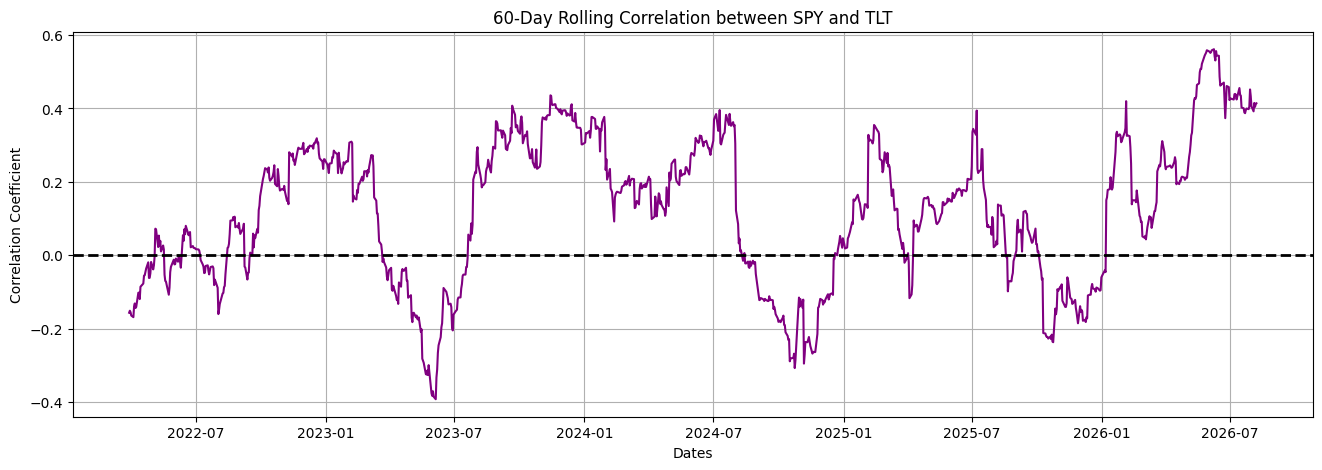

In [ ]:
# 1. To calculate correlation on returns using your list pattern,
# we first compute daily percentage returns from your y7points and y8points price lists


#build up the percentage returns array
spy_returns_list = []
tlt_returns_list = []

# Loop from the second day to the end to calculate (Price_Today - Price_Yesterday) / Price_Yesterday

#compute the percentage returns
for i in range(1, len(y7points)):
    spy_ret = (y7points[i] - y7points[i-1]) / y7points[i-1]
    tlt_ret = (y8points[i] - y8points[i-1]) / y8points[i-1]
    spy_returns_list.append(spy_ret)
    tlt_returns_list.append(tlt_ret)

#build a dataframe for the returns and ensure to slice the date index [1:] because the very first day has no prior return data
returns_df = pd.DataFrame({
    "SPY_Daily_Return": spy_returns_list,
    "TLT_Daily_Return": tlt_returns_list
}, index=x7points[1:])

#Compute the 60-day rolling correlation using the series from the returns_df dataframe
returns_df["Rolling_Correlation"] = (
    returns_df["SPY_Daily_Return"]
    .rolling(window=60)
    .corr(returns_df["TLT_Daily_Return"])
)

#the high correlation dataframe contains the data where the rolling correlation > 0.5
high_corr_df = returns_df[returns_df["Rolling_Correlation"] > 0.5]

print(returns_df)


plt.figure(figsize=(16, 5))
plt.plot(returns_df.index, returns_df["Rolling_Correlation"], color="purple")
plt.axhline(y=0, color="black", linestyle="--", linewidth=2)
plt.xlabel("Dates")
plt.ylabel("Correlation Coefficient")
plt.title("60-Day Rolling Correlation between SPY and TLT")
plt.grid()
plt.show()

In [ ]:


#get the SPY AND TLT series from the returns_df
spy_series = returns_df["SPY_Daily_Return"]
tlt_series = returns_df["TLT_Daily_Return"]

spy_mean = spy_series.mean()
spy_min = spy_series.min()
spy_max = spy_series.max()
spy_std = spy_series.std()

print(f"  SPY Mean : {round((spy_mean), 6)}")
print(f"  SPY Minimum : {round(spy_min, 6)} ")
print(f"  SPY Maximum :  {round(spy_max, 6)} ")
print(f"  SPY Standard:   {round(spy_std, 6)} ")

tlt_mean = tlt_series.mean()
tlt_min = tlt_series.min()
tlt_max = tlt_series.max()
tlt_std = tlt_series.std()


print(f"  TLT Mean : {round((tlt_mean), 6)}")
print(f"  TLT Minimum : {round(tlt_min, 6)} ")
print(f"  TLT Maximum :  {round(tlt_max, 6)} ")
print(f"  TLT Standard Deviation :   {round(tlt_std, 6)}")


  SPY Mean : 0.000536
  SPY Minimum : -0.058543 
  SPY Maximum :  0.105019 
  SPY Standard:   0.011042 
  TLT Mean : -0.00031
  TLT Minimum : -0.034183 
  TLT Maximum :  0.038473 
  TLT Standard Deviation :   0.009971
